# PyTorch

PyTorch is an open-source deep learning library in Python, known for its efficiency, flexibility, and user-friendliness.

These might be some reasons why it is one of the most widely used deep learning libraries for building neural networks.

PyTorch serves three main purposes:

1) PyTorch is a tensor library. Tensors are more advanced forms of vectors and arrays, similar to those known from NumPy. The specialty of tensors is their optimization for accelerated computation on GPUs.
2) PyTorch includes an automatic differentiation engine, which automatically calculates the gradients of the loss function. This tremendously simplifies the process of building a neural network because you only have to define the network structure, eliminating the necessity of calculating the gradients manually.
3) Last but not least, PyTorch is a deep learning library which provides building blocks for the creation of your custom neural networks, including the most common loss functions and optimizers.



## Installing PyTorch

In [149]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


First, we need to import all required libraries.

In [150]:
import torch
import torch.nn as nn   
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

For reproducibility, we can set a seed.
I have chosen 42, because 42 is the answer to everything.

In [151]:
torch.manual_seed(42)

The current version and whether CUDA is available on your machine can be checked with the following code block.

In [152]:
torch.__version__
torch.cuda.is_available()

False

## Introduction into Pytorch Tensors

Tensors are mathematical objects characterized by their dimensions (also called rank). They are a fundamental data structure used in deep learning and scientific computing.

A tensor can be thought of as a generalization of scalars, vectors, and matrices:

- A scalar is a zero-dimensional tensor (just a single number).
- A vector is a one-dimensional tensor (a list of numbers).
- A matrix is a two-dimensional tensor (a table of numbers).
- Tensors can have even more dimensions (for example, a 3D tensor could represent an RGB image with width, height, and color channels).

Tensors are very similar to NumPy arrays. In fact, many operations and syntax in PyTorch tensors are designed to resemble those in NumPy, making it easy to switch between the two. 

But tensors include additional features crucial for deep learning, such as the ability to run computations on GPUs and to automatically compute gradients for backpropagation.

In [153]:
# zero-dimensional tensor# (scalar)
torch.tensor(1)

# one-dimensional tensor# (vector)
torch.tensor([1, 2, 3])

# two-dimensional tensor# (matrix)
torch.tensor([[1, 2, 3], [4, 5, 6]])

# three-dimensional tensor# (3D tensor)
torch.tensor([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])

tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[ 7,  8,  9],
         [10, 11, 12]]])

PyTorch default datatype for integer tensors is int64, and for float tensors is float32.
The 32-bit floating point numbers were chosen to balance precision and the consumption of computational resources.
But if high precision is a crucial point in your application, you can also convert the tensor into a float64 datatype.

In [154]:
# Initializing a tensor with integers
my_int_tensor = torch.tensor([[1, 2, 3, 4], [4, 5, 6, 7]])
print(my_int_tensor.dtype) 

# Initializing a tensor with floats
my_float_tensor = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(my_float_tensor.dtype)

# Converting a float32 tensor to float64
my_float_tensor = my_float_tensor.to(torch.float64)
print(my_float_tensor.dtype)

torch.int64
torch.float32
torch.float64


We can change the dimensions of our initial tensor using the following three methods:

1) The `.reshape` method returns a new tensor in the defined shape without modifying the original tensor.

2) The `.view` method also returns a new tensor in the defined shape but requires the tensor to be contiguous in memory and is often used for efficient reshaping.
Contiguous in memory means that the tensor's elements are stored in an unbroken, sequential block of memory, without any gaps or reordering.
Non-contiguous tensors can result from certain operations, like transposing. We can make a tensor contiguous by calling `.contiguous()`.

3) PyTorch's `.T` is a shorthand for the transpose operation, which swaps the dimensions of a tensor, meaning rows become columns and vice versa.


In [155]:
# tensor shape
my_int_tensor.shape

torch.Size([2, 4])

In [156]:
my_int_tensor.reshape(4, 2)

tensor([[1, 2],
        [3, 4],
        [4, 5],
        [6, 7]])

In [157]:
my_int_tensor.view(4, 2)

tensor([[1, 2],
        [3, 4],
        [4, 5],
        [6, 7]])

In [158]:
my_int_tensor.T

tensor([[1, 4],
        [2, 5],
        [3, 6],
        [4, 7]])

In [159]:
# This won't work
# my_int_tensor.T.view(2, 4)

# This will work
my_int_tensor.T.contiguous().view(2, 4)

tensor([[1, 4, 2, 5],
        [3, 6, 4, 7]])

## Dataset

Imagine working at a telecom company. In the following simplified example we would like to predict whether a customer will leave the service ("churn") based on two features: 
 1) monthly usage (hours/month)
 2) support calls (number of support calls per month)

There is a binary outcome (1 = churned, 0 = stayed)
For the sake of simplicity our dataset will only consist of 10 customers in the test set and 2 customers in the training set. 

For the training of a real-world scenario neural network thousands of datapoints would be necessary for accurate predictions.

In [160]:
X_train = torch.tensor([
    [10.0, 8.0],
    [11.0, 9.5],
    [12.0, 7.8],
    [13.0, 9.0],
    [40.0, 2.0],
    [42.0, 3.0],
    [44.0, 1.5],
    [45.0, 1.8],
    [46.0, 2.2],
    [48.0, 1.9],
    [49.0, 2.5],
], dtype=torch.float32)

y_train = torch.tensor([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], dtype=torch.float32)
y_train = y_train.view(-1, 1)

Moreover, let's create a test dataset to use later when evaluating the final model.

In [161]:
X_test = torch.tensor([
        [15.0,  9.0],
        [42.3,  2.3],
], dtype=torch.float32)

y_test = torch.tensor([1, 0], dtype=torch.float32)
y_test = y_test.view(-1, 1)

## Feature Standardization Implementation

Features have different scales (monthly usage: 10-49 vs support calls: 1.5-9.5), which causes training instability. We'll normalize them to have mean=0 and std=1.

In [162]:
# Examine original data ranges
print(f"Monthly usage: {X_train[:, 0].min():.1f} - {X_train[:, 0].max():.1f}")
print(f"Support calls: {X_train[:, 1].min():.1f} - {X_train[:, 1].max():.1f}")
print(f"Scale difference: {X_train[:, 0].max() / X_train[:, 1].max():.1f}x")

Monthly usage: 10.0 - 49.0
Support calls: 1.5 - 9.5
Scale difference: 5.2x


This is achieved by applying the standard z-score normalization formula.

$$
\text{normalized\ value} = \frac{x - \text{mean}}{\text{standard\ deviation}}
$$

In [163]:
# Standardization: (x - mean) / std
train_mean = X_train.mean(dim=0) # Average of each feature
train_std = X_train.std(dim=0)   # Standard deviation of each feature

# Apply to both train and test data
X_train_normalized = (X_train - train_mean) / train_std 
X_test_normalized = (X_test - train_mean) / train_std

In the next step a custom dataset class is implemented, which inherits from the PyTorch Dataset class.

In its simplest form this class consists of three methods.
1) The `__init__` method to initialize the class
2) The `__len__` method to return the number of datapoints in the dataset. This allows to run `len(ds_train)` later.
3) The `__getitem__` method to get a specific item from the dataset by its id. It allows to run `ds_train[0]` later.

In [164]:
class ChurnDataset(Dataset):
    def __init__(self, X, y):
        self.features = X
        self.labels = y

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]
    
ds_train = ChurnDataset(X_train_normalized, y_train)
ds_test = ChurnDataset(X_test_normalized, y_test)

## Dataloader

Subsequently, we can sample from the previously created dataset, using the PyTorch `DataLoader` class. 

The last datapoint in the training dataset is neglected, because of `drop_last=True`. This is recommended, because a smaller batch size in the end can disturb the convergence during training. Thus it is better to ignore it.

In [165]:
# Set seed again before DataLoader for reproducible shuffling
torch.manual_seed(42)

# Use normalized datasets for training
train_loader = DataLoader(dataset=ds_train, batch_size=2, shuffle=True, drop_last=False)
test_loader = DataLoader(dataset=ds_test, batch_size=2, shuffle=False, drop_last=False)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print("Note: Removed drop_last=True to use all available data")

Training batches: 6
Test batches: 1
Note: Removed drop_last=True to use all available data


Neural Networks are typically trained in batches, where the size of a batch is a hyperparameter that needs to be figured out.

In case of a single sample (batch size = 1), the gradient can be very noisy and unstable, making learning slow or erratic.

When all data points are used at once (full batch or batch gradient descent), the best estimate is achieved. But it's often too slow and memory-intensive for large datasets. 

Batches (mini-batch gradient descent) are a sweet spot. They average out some of the noise but don't require processing the entire dataset at once.

Now, let's iterate through the generated batches.

In [166]:
for id, (features, labels) in enumerate(train_loader):
    print(f"Batch {id + 1}:")
    print("Features:\n", features)
    print("Labels:\n", labels)
    print()


Batch 1:
Features:
 tensor([[ 0.5447, -0.4456],
        [ 0.9559, -0.5969]])
Labels:
 tensor([[0.],
        [0.]])

Batch 2:
Features:
 tensor([[ 0.7796, -0.6877],
        [-1.2763,  1.5212]])
Labels:
 tensor([[0.],
        [1.]])

Batch 3:
Features:
 tensor([[-1.3350,  1.0673],
        [ 0.8971, -0.7785]])
Labels:
 tensor([[1.],
        [0.]])

Batch 4:
Features:
 tensor([[-1.2175,  1.0068],
        [ 0.6622, -0.8995]])
Labels:
 tensor([[1.],
        [0.]])

Batch 5:
Features:
 tensor([[-1.1588,  1.3699],
        [ 0.7209, -0.8087]])
Labels:
 tensor([[1.],
        [0.]])

Batch 6:
Features:
 tensor([[ 0.4272, -0.7482]])
Labels:
 tensor([[0.]])



## Computational Graph

The second key benefit, which PyTorch offers is its autograd system.
This system computes automatically the gradient of a dynamic computational graph.
Computational graphs are directed graphs expressing and visualizing mathematical expressions. 
This graph expresses the sequence of calculations in the neural network required to compute the final output.

In [167]:
class SimpleLogisticRegression(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.linear = nn.Linear(input_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        logits = self.linear(x)
        return self.sigmoid(logits)

In the next step we can define the number of input dimensions/features and output features.

In [168]:
torch.manual_seed(42)  # Set seed for reproducibility

model = SimpleLogisticRegression(input_size=2, output_size=1)  # Changed to 1 output for binary classification

The model architecture can be checked by just printing out the model

In [169]:
print(model)

SimpleLogisticRegression(
  (linear): Linear(in_features=2, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


Moreover, we can inspect the initial weights of the model, which are initialized with small random numbers.  
These random initializations with small random numbers allow to break symmetry during training.  
Without this random initialization the model would perform the same operation and updates, which hinders the model to learn.

In [170]:
print(f"Initial weights: {model.linear.weight.data}")
print(f"Initial weights: {model.linear.weight}")
print(f"Initial bias: {model.linear.bias}")

Initial weights: tensor([[0.5406, 0.5869]])
Initial weights: Parameter containing:
tensor([[0.5406, 0.5869]], requires_grad=True)
Initial bias: Parameter containing:
tensor([-0.1657], requires_grad=True)


We can check the model's output based on the randomly initialized weights for our first sample.

In [171]:
output = model(X_train_normalized[0])
print(f"Input sample: {X_train_normalized[0]}")
print(f"Output for first sample: {output.item():.4f}")

Input sample: tensor([-1.3350,  1.0673])
Output for first sample: 0.4351


## Model Training

So far our model only consists of random weights, resulting in random outputs.   
This can be changed by training the model.  
Neural Networks are learning based on backpropagation. 
Backpropagation is an algorithm that calculates the gradient of the loss function with respect to each weight in a neural network by propagating the error backward from the output layer to the input layer.
In simple terms backpropagation answers the question: "How does the weights have to be adjusted so that the predicted output matches the value?"
How far these two values are away from each other is determined by a loss function.
A common loss function for a binary prediction problem is the binary cross entropy loss, used in this example.
$$
\text{BCE}(y, \hat{y}) = -\left[ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \right]
$$
Binary cross entropy loss measures the difference between the true binary label $y$ and the predicted probability $\hat{y}$​, penalizing the model more as its predicted probability diverges from the actual label.



In [172]:
criterion = nn.BCELoss()


Based on this loss value all weights are adjusted in the neural network.
For these updates stochastic gradient descent is used.  
Stochastic Gradient Descent is an optimization algorithm that updates the model's weights using the gradient from a single or small batch of data at a time.
In this manner, SGD increases efficiency and allows to escape local minima.  
The learning rate determines the step size of the update. The learning rate is a hyperparameter. If it is chosen too small the algorithm converges too slow. If the learning rate is chosen too large the algorithm overshoots the minimum.

In [173]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

Now we can start the training loop for iteratively updating our weights of the neural network.

The two most important terms for training a neural network are epoch and batch:

An epoch is one complete pass through the entire training dataset. After each epoch, the model has seen every example in the dataset once.
A batch is a subset of the training data used to compute a single update to the model's parameters. Instead of updating the model after every individual data point, which is slow, or after the whole dataset, which can be memory intensive.

In the following example we use 100 epochs. So the model sees the dataset 100 times and updates its weights according to the loss. 
The average epoch loss is stored in a list for later visualization.


In [174]:
# Set seed before training for reproducible training behavior
torch.manual_seed(42)

# Training loop
num_epochs = 100
train_losses = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    
    # Set model to training mode
    model.train()
    
    # Iterate through batches
    for batch_idx, (features, labels) in enumerate(train_loader):
        # Clear gradients from previous iteration
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(features)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backward pass (compute gradients)
        loss.backward()
        
        # Update parameters
        optimizer.step()
        
        # Accumulate loss for this epoch
        epoch_loss += loss.item()
    
    # Store average loss for this epoch
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("\nTraining completed!")
print(f"Final weights: {model.linear.weight.data}")
print(f"Final bias: {model.linear.bias.data}")

Epoch [10/100], Loss: 0.4770
Epoch [20/100], Loss: 0.3663
Epoch [30/100], Loss: 0.2813
Epoch [40/100], Loss: 0.2308
Epoch [50/100], Loss: 0.1993
Epoch [60/100], Loss: 0.1726
Epoch [70/100], Loss: 0.1529
Epoch [80/100], Loss: 0.1339
Epoch [90/100], Loss: 0.1199
Epoch [100/100], Loss: 0.1109

Training completed!
Final weights: tensor([[-0.5994,  1.6949]])
Final bias: tensor([-0.5271])


In the subsequent visualization we can see how the epoch loss decreases over time, due to the adjustments of weights.

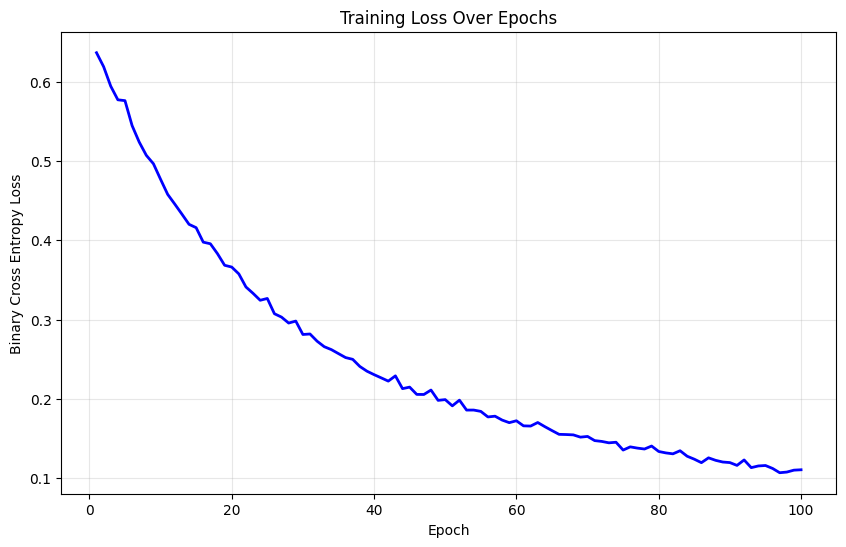

Initial loss: 0.6364
Final loss: 0.1109
Loss reduction: 82.6%


In [175]:
# Visualize training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, 'b-', linewidth=2)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross Entropy Loss')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial loss: {train_losses[0]:.4f}")
print(f"Final loss: {train_losses[-1]:.4f}")
print(f"Loss reduction: {((train_losses[0] - train_losses[-1]) / train_losses[0] * 100):.1f}%")

## Evaluation

However, just because the model performs well on the training dataset. It does not mean, that it also performs well on new unseen data.  
There is always the risk, that the model might memorize the data instead of learning the overall pattern, which is referred to as overfitting.
We can check this by the following evaluation.

In [176]:
# Evaluate the model on test set
model.eval()

with torch.no_grad():  # Disable gradient computation for evaluation
    test_features, test_labels = next(iter(test_loader))
    test_labels = test_labels.view(-1, 1)
    
    # Make predictions
    test_outputs = model(test_features)
    test_loss = criterion(test_outputs, test_labels)
    
    # Convert probabilities to binary predictions (threshold = 0.5)
    test_predictions = (test_outputs > 0.5).float()
    
    # Calculate accuracy
    correct = (test_predictions == test_labels).float().sum()
    accuracy = correct / len(test_labels)
    
    print("Test Results:")
    print(f"Test Loss: {test_loss.item():.4f}")
    print(f"Test Accuracy: {accuracy.item():.2%}")
    
    # Show predictions vs actual
    for i in range(len(test_features)):
        prob = test_outputs[i].item()
        actual = test_labels[i].item()
        print(f"Sample {i+1}: Probability={prob:.3f}, Actual={'Churn' if actual else 'Stay'}")

Test Results:
Test Loss: 0.1074
Test Accuracy: 100.00%
Sample 1: Probability=0.918, Actual=Churn
Sample 2: Probability=0.121, Actual=Stay


Even though the model predicted both samples of the training dataset correctly, this does not mean that the model functions perfectly.  
It has to be mentioned that the dataset in this post is far too small for the task.
Both training and evaluation require more data samples for building and assessing a model for this task. 
However, the general recipe keeps the same independent of the dataset or model size.